# Pandas: A Comprehensive Tutorial

Welcome to the Ultimate Pandas Guide

This deeply structured, comprehensive tutorial is designed to take you from a basic understanding of Python to a master of Data Engineering tailored for Material Sciences. We focus on breadth and, more importantly, immense depth—repeating concepts using varying syntax to build deep "muscle memory."  
We will explore classic datasets for foundational operations, and heavily utilize `matplotlib` and `seaborn` across all topics.  
Finally, you will execute a capstone analytical report on a real Nylon-6 Tensile Testing `.xlsx` dataset to auto-identify the Yield Point, Ultimate Tensile Strength (UTS), and compute Young's Modulus and Toughness.


## 1. Core Data Structures: Series and DataFrames

### 1.1 The Series Object
A Series is a one-dimensional array-like object capable of holding any data type (integers, strings, floats, Python objects, etc.). It is the basic unit of a Pandas DataFrame.


In [1]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import scipy.stats as stats 
import scipy.integrate as integrate 

# Set styles for beautiful academic graphs as requested
plt.style.use('seaborn-v0_8-whitegrid') 
sns.set_context("notebook", font_scale=1.2) 

# Set seed for reproducibility
np.random.seed(42) 

print("Pandas version:", pd.__version__) 
print("Libraries imported successfully. Ready for data science!")


Pandas version: 3.0.2
Libraries imported successfully. Ready for data science!


In [2]:
# Example 1.1.1: Creating a Series from a list 
# In material science, we often track a sequence of readings, like temperature or load over time.
# Method 1: Standard List Construction
temperatures_list = [298.15, 300.0, 315.5, 400.2] 
temp_series = pd.Series(temperatures_list)

print("Standard Series Creation:")
print(temp_series)
print("\nType of our object:", type(temp_series))


Standard Series Creation:
0    298.15
1    300.00
2    315.50
3    400.20
dtype: float64

Type of our object: <class 'pandas.Series'>


In [3]:
# Example 1.1.2: Creating a Series with Custom Indexing 
# Let's say we want to label our temperatures with specific sample names or time points. 
# Method 2: Providing a custom 'index' argument
sample_labels = ['Sample_A', 'Sample_B', 'Sample_C', 'Sample_D']
temp_series_labeled = pd.Series(temperatures_list, index=sample_labels)

print("Labeled Series Creation:")
print(temp_series_labeled)


Labeled Series Creation:
Sample_A    298.15
Sample_B    300.00
Sample_C    315.50
Sample_D    400.20
dtype: float64


In [4]:
# Example 1.1.3: Creating a Series from a Dictionary
# Dictionaries inherently map keys (which become the Series index) to values.
alloy_melting_points = {
    'Steel_304': 1400,
    'Aluminum_6061': 582,
    'Titanium_Grade5': 1604,
    'Copper_C11000': 1085
} 
melting_series = pd.Series(alloy_melting_points)

print("Dictionary to Series:")
print(melting_series)

# Notice how the keys automatically became the index.


Dictionary to Series:
Steel_304          1400
Aluminum_6061       582
Titanium_Grade5    1604
Copper_C11000      1085
dtype: int64


### 1.2 Accessing Series Elements (Indexing and Slicing) 
Just like Numpy arrays, Pandas Series can be accessed by their positional integer index or by their custom label index.


In [5]:
# Example 1.2.1: Positional Indexing vs Label Indexing
print("1. Accessing via position (iloc logic):")
print("First element:", melting_series.iloc[0])   # Outputs 1400
print("Last element:", melting_series.iloc[-1])  # Outputs 1085

print("\n2. Accessing via label (loc logic):")
print("Melting point of Titanium Grade 5:", melting_series.loc['Titanium_Grade5'])


1. Accessing via position (iloc logic):
First element: 1400
Last element: 1085

2. Accessing via label (loc logic):
Melting point of Titanium Grade 5: 1604


In [6]:
# Example 1.2.2: Vectorized Operations on Series
# Pandas inherits vectorization from Numpy. You can apply mathematical operations 
# across the entire Series without writing 'for' loops!
# Let's convert our melting points from Celsius to Fahrenheit.
# Formula: F = (C * 9/5) + 32

melting_series_fahrenheit = (melting_series * 9/5) + 32

print("Melting Points in Fahrenheit:")
print(melting_series_fahrenheit)


Melting Points in Fahrenheit:
Steel_304          2552.0
Aluminum_6061      1079.6
Titanium_Grade5    2919.2
Copper_C11000      1985.0
dtype: float64



### 1.2 Dictionary vs Dictionary of Lists Example

In [7]:

# Dictionary vs Dictionary of Lists Example

# Simple dictionary: one value per key
student_scores = {
    "Alice": 85,
    "Bob": 92,
    "Charlie": 78
}

# Dictionary of lists: multiple values per key
student_grades = {
    "Alice": [85, 90, 88],      # Multiple quiz scores
    "Bob": [92, 95, 91],
    "Charlie": [78, 82, 80]
}

# Accessing data
print(f"Alice's single score: {student_scores['Alice']}")
print(f"Alice's all scores: {student_grades['Alice']}")
print(f"Alice's average: {sum(student_grades['Alice']) / len(student_grades['Alice']):.1f}")



Alice's single score: 85
Alice's all scores: [85, 90, 88]
Alice's average: 87.7


### 1.3 The DataFrame Object
A DataFrame is a two-dimensional, size-mutable, potentially heterogeneous tabular data structure with labeled axes (rows and columns). Think of it like a programmatic Excel spreadsheet.


In [8]:
# Example 1.3.1: Creating a DataFrame from a dictionary of lists.
# This is one of the most common ways to manually construct a DataFrame.
# Imagine an experiment tracking three different alloy compositions.
alloy_data = {
    'Alloy_Name': ['Al-6061', 'Ti-6Al-4V', 'SS-316L', 'Inconel-718'], 
    'Density_g_cm3': [2.70, 4.43, 7.99, 8.19],
    'Yield_Strength_MPa': [276, 880, 205, 1034],
    'Cost_per_kg_USD': [3.5, 45.0, 5.2, 80.0]
}

df_alloys = pd.DataFrame(alloy_data) 

print("DataFrame constructed from dictionary:")
display(df_alloys) # 'display' is superior to 'print' in Jupyter Notebooks! 


DataFrame constructed from dictionary:


,Alloy_Name,Density_g_cm3,Yield_Strength_MPa,Cost_per_kg_USD
0,Al-6061,2.70,276,3.5
1,Ti-6Al-4V,4.43,880,45.0
2,SS-316L,7.99,205,5.2
3,Inconel-718,8.19,1034,80.0


In [9]:
# Example 1.3.2: Creating a DataFrame from a 2D Numpy Array
# Often, scientific tools output raw Numpy matrices. We can wrap them in a DataFrame for better handling.
raw_matrix = np.array([
    [10.5, 20.1, 0.4],
    [11.2, 19.8, 0.5],
    [9.8, 21.0, 0.45]
])

# If we pass raw data, Pandas assigns integer labels (0, 1, 2) by default.
# We should provide 'columns' for clarity.
df_matrix = pd.DataFrame(
    data=raw_matrix, 
    columns=['Feature_X', 'Feature_Y', 'Feature_Z'],
    index=['Test_1', 'Test_2', 'Test_3']
)

display(df_matrix)


,Feature_X,Feature_Y,Feature_Z
Test_1,10.5,20.1,0.40
Test_2,11.2,19.8,0.50
Test_3,9.8,21.0,0.45


#### 1.3.1 Introducing np.randm.choice function

In [10]:
# Generates a random sample from a given 1-D array
# help(np.random.choice)
# np.random.choice(a, size, replace=True, p)
np.random.choice(np.array(['A', 'B', 'C', 'D', 'E']), size=10, replace=True)


array(['D', 'E', 'C', 'E', 'E', 'B', 'C', 'C', 'C', 'E'], dtype='<U1')

#### 1.3.2 Introducing np.random.normal function

In [11]:
#  Draw random samples from a normal (Gaussian) distribution.
# help(np.random.normal)
# np.random.normal(loc, scale, size)
np.random.normal(loc=0, scale=0.5, size=(2,3,2,3))


array([[[[ 0.78960641,  0.38371736, -0.23473719],
         [ 0.27128002, -0.23170885, -0.23286488]],

        [[ 0.12098114, -0.95664012, -0.86245892],
         [-0.28114376, -0.50641556,  0.15712367]],

        [[-0.45401204, -0.70615185,  0.73282438],
         [-0.11288815,  0.0337641 , -0.71237409]]],


       [[[-0.27219136,  0.05546129, -0.57549679],
         [ 0.18784901, -0.30031934, -0.14584687]],

        [[-0.30085331,  0.92613909, -0.00674861],
         [-0.52885546,  0.41127246, -0.61042182]],

        [[ 0.1044318 , -0.97983506, -0.66409302],
         [ 0.09843062,  0.36923329,  0.08568414]]]])

#### 1.3.3 Introducing np.random.lognormal function

Log Normal Distribution:

$$Y=\ln{x}  \sim  \mathcal{N}(\mu, \sigma^2)$$

In [12]:
help(np.random.lognormal)
# np.random.lognormal(mean, sigma, size)


Help on method lognormal in module numpy.random:

lognormal(mean=0.0, sigma=1.0, size=None) method of numpy.random.mtrand.RandomState instance
    lognormal(mean=0.0, sigma=1.0, size=None)

    Draw samples from a log-normal distribution.

    Draw samples from a log-normal distribution with specified mean,
    standard deviation, and array shape.  Note that the mean and standard
    deviation are not the values for the distribution itself, but of the
    underlying normal distribution it is derived from.

    .. note::
        New code should use the `~numpy.random.Generator.lognormal`
        method of a `~numpy.random.Generator` instance instead;
        please see the :ref:`random-quick-start`.

    Parameters
    ----------
    mean : float or array_like of floats, optional
        Mean value of the underlying normal distribution. Default is 0.
    sigma : float or array_like of floats, optional
        Standard deviation of the underlying normal distribution. Must be
        non-

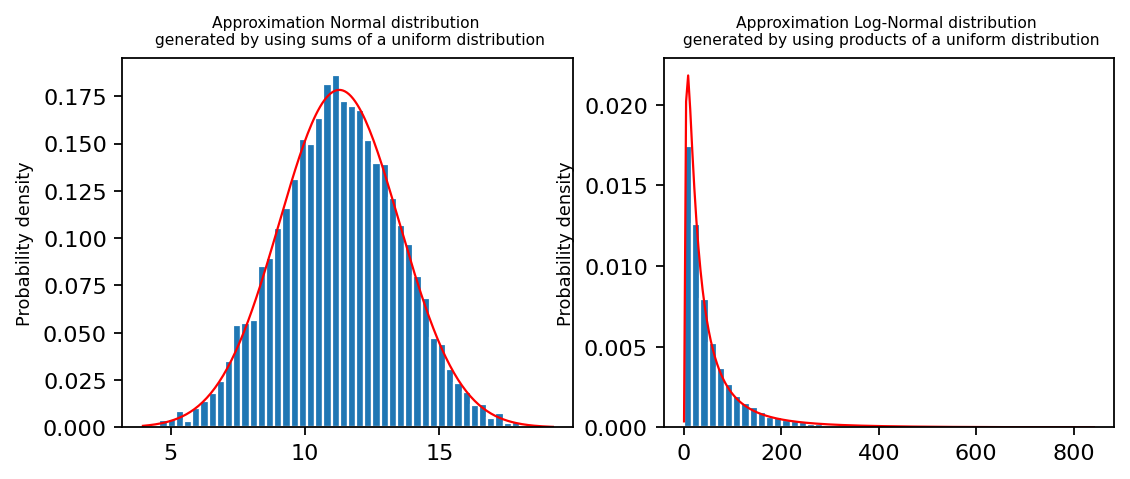

 Approximation Normal distribution informations:
 normal_mean: 11.2751   normal_sigma:  2.2371

 Approximation Log-Normal distribution information:
 Log_mean: 3.4337    log_sigma: 1.1993


In [1]:


import numpy as np
import matplotlib.pyplot as plt

# Generating Normal Distribution and Log-Normal Distribution by using sums and products of uniform random variables.

rng= np.random.default_rng(seed=95)

normal_samples = [] 
log_normal_samples= [] 

for i in range(10000):
    unif_random_number = rng.uniform(low=0.5, high=4.0, size=5)
    normal_samples.append( np.sum(unif_random_number)) 
    log_normal_samples.append(np.prod(unif_random_number)) 


fig , ax = plt.subplots(1, 2, figsize=(8,3), dpi=160)
count0, bins0, _ =ax[0].hist(normal_samples, bins=50, density=True, edgecolor=(1,1,1))

normal_mean = np.mean( normal_samples )
normal_sigma= np.std(normal_samples)

x_normal= np.linspace(start=np.min(bins0), stop=np.max(bins0), num=200) 

pdf_normal= 1/(normal_sigma  * np.sqrt(2 * np.pi)) * np.exp(- ((x_normal- normal_mean)**2)/(2 * normal_sigma**2))

ax[0].plot(x_normal, pdf_normal, linewidth= 1, color='red')
ax[0].set_title("Approximation Normal distribution \n generated by using sums of a uniform distribution", fontsize=7)
ax[0].set_ylabel("Probability density", fontsize=8)

# Approximation Log-Normal Distribution generated by using products of Uniform distribution 

log_mean= np.mean(np.log(log_normal_samples))
log_sigma= np.std(np.log(log_normal_samples))

count1, bins1, _ = ax[1].hist(log_normal_samples, bins=50, density= True, edgecolor=(1,1,1))
x_log= np.linspace(start= np.min(bins1), stop= np.max(bins1), num=200)
pdf_log= 1/(x_log * log_sigma * np.sqrt(2 * np.pi)) * np.exp( - (( np.log(x_log) - log_mean)**2)/( 2* log_sigma**2) )

ax[1].plot(x_log, pdf_log, linewidth= 1, color="red")
ax[1].set_title("Approximation Log-Normal distribution \n generated by using products of a uniform distribution", fontsize=7)
ax[1].set_ylabel("Probability density", fontsize=8)
plt.show()
print(f" Approximation Normal distribution informations:")
print(f" normal_mean: {normal_mean:.4f}   normal_sigma:  {normal_sigma:.4f}") 
print(f"\n Approximation Log-Normal distribution information:")
print(f" Log_mean: {log_mean:.4f}    log_sigma: {log_sigma:.4f}")


In [20]:
a= 1 + 0.5 * np.random.standard_normal(2)
b= np.prod(a)
print(repr(a))
print(repr(b))

c=[]
for i in range(5):
    d= 1 + np.random.standard_normal(2)
    c.append(np.prod(d))
print(type(c))
print(repr(c))
print(c)
print([float(x) for x in c])
print([f"{float(x):.4f}" for x in c])
print(np.log(2.71828))


array([0.50473184, 0.71685114])
np.float64(0.36181759063591534)
<class 'list'>
[np.float64(0.5460036747503696), np.float64(-0.5884185540169204), np.float64(-0.09181028094724941), np.float64(0.2054629173378598), np.float64(0.1469409343609831)]
[np.float64(0.5460036747503696), np.float64(-0.5884185540169204), np.float64(-0.09181028094724941), np.float64(0.2054629173378598), np.float64(0.1469409343609831)]
[0.5460036747503696, -0.5884185540169204, -0.09181028094724941, 0.2054629173378598, 0.1469409343609831]
['0.5460', '-0.5884', '-0.0918', '0.2055', '0.1469']
0.999999327347282


In [ ]:
a=np.random.standard_normal(10)
b= 2 + a
c=[]
d=np.prod(b)

print(repr(b))
print(repr(c))
print(type(c))
print(repr(d))

e=[]
h=[]
for i in range(10):
    f= 1+ 1
    g=1+ np.random.standard_normal(10) 
    e.append(f)
    h.append(np.prod(g)) 
print(repr(e)) 
print(repr(h))


### 1.4 Inspecting DataFrames
When you load massive datasets, you cannot print them entirely. You must use inspection tools to understand the metadata and statistical summaries.


In [ ]:
# Example 1.4.1: Building a massive synthetic dataset to practice inspection.
# We will simulate 10,000 synthetic tensile test results for generic analysis.
num_samples = 10000
synthetic_df = pd.DataFrame({
    'Sample_ID': range(1, num_samples + 1),
    'Material_Class': np.random.choice(['Polymer', 'Metal', 'Ceramic', 'Composite'], num_samples, p=[0.4, 0.4, 0.1, 0.1]),
    'Test_Temperature_C': np.random.normal(25, 5, num_samples).round(1), # Mean 25C, Std 5C
    'Yield_Strength_MPa': np.random.lognormal(mean=5, sigma=1, size=num_samples).round(2),
    'Failed_Before_Yield': np.random.choice([True, False], num_samples, p=[0.05, 0.95]),
    'Operator_Name': np.random.choice(['Alice', 'Bob', 'Charlie', 'Diana'], num_samples)
})

# Let's inspect the first 5 rows using .head()
print("Top 5 rows (.head):")
display(synthetic_df.head())

# Let's inspect the last 3 rows using .tail()
print("\nBottom 3 rows (.tail):")
display(synthetic_df.tail(3))


In [ ]:
# Example 1.4.2: Data Types and Info
# .info() is the most critical method for checking data types and finding missing values immediately.
print("Dataset Metadata via .info():")
synthetic_df.info()


In [ ]:
# Example 1.4.3: Statistical Summary
# .describe() computes mean, standard deviation, min, max, and quantiles instantly.
# By default, it ignores non-numerical features like 'Operator_Name' or 'Material_Class'.
print("Summary Statistics via .describe():")
display(synthetic_df.describe())


In [ ]:
# Example 1.4.4: Examining categorical columns
# We can use .value_counts() on a specific column to see the frequency of categories.
print("Count of tests by Material Class:")
print(synthetic_df['Material_Class'].value_counts())

print("\nCount of tests by Operator, normalized (percentages):")
print(synthetic_df['Operator_Name'].value_counts(normalize=True) * 100)


## 2. Advanced Selection, Filtering, and Indexing
Now that data is inside a DataFrame structure, how do we precisely extract the slices we need? We use `loc`, `iloc`, and conditional indexing.


In [ ]:
# Example 2.1.1: Single Column Selection
# Method 1: Dictionary-style string indexing (Recommended robust method)
yield_col = synthetic_df['Yield_Strength_MPa']
print("Type of a single column extraction:", type(yield_col))
print(yield_col.head(3))

# Method 2: Dot notation (Quick, but fails if column name has spaces or matches a method name like 'mean')
temp_col = synthetic_df.Test_Temperature_C


In [ ]:
# Example 2.1.2: Multiple Column Selection
# Pass a LIST of column strings to extract a sub-DataFrame.
# Notice the double brackets [[ ]]! The outer brackets are the indexer, the inner is the Python list.
subset_df = synthetic_df[['Sample_ID', 'Material_Class', 'Yield_Strength_MPa']]
display(subset_df.head())


In [ ]:
# Example 2.2.1: Row Selection via .iloc (Integer Location)
# .iloc strictly uses ZERO-BASED INTEGER array indexing, just like Numpy or pure Python lists.
# syntax: df.iloc[row_indices, column_indices]

# Grab the very first row (index 0)
first_row = synthetic_df.iloc[0]
print("First row data:")
print(first_row)

# Grab rows 10 to 15, and columns 1 to 3
subset_slice = synthetic_df.iloc[10:16, 1:4]
print("\nSliced DataFrame using .iloc:")
display(subset_slice)


In [ ]:
# Example 2.2.2: Row Selection via .loc (Label Location)
# .loc strictly uses labels (the names of the index and the names of the columns).
# In our synthetic_df, the index happens to be integers 0, 1, 2... but they are treated as labels here.
# df.loc[row_labels, column_labels]

subset_loc = synthetic_df.loc[0:5, ['Material_Class', 'Yield_Strength_MPa']]
# Note a crucial difference: loc[0:5] INCLUDES 5, whereas iloc[0:5] STOPS at 4!
display(subset_loc)


### 2.3 Boolean Indexing (Filtering)
Filtering data based on logical conditions is the bread and butter of data clean-up. We use standard bitwise operators: `&` (AND), `|` (OR), `~` (NOT).
**Crucial Rule:** Always wrap each individual condition in parentheses `()`.


In [ ]:
# Example 2.3.1: Simple condition filtering
# We want all rows where the Test_Temperature_C is precisely 25.0
standard_temp_mask = synthetic_df['Test_Temperature_C'] == 25.0
standard_temp_tests = synthetic_df[standard_temp_mask]

print(f"Out of {len(synthetic_df)} tests, {len(standard_temp_tests)} were conducted at exactly 25.0C.")
display(standard_temp_tests.head(3))


In [ ]:
# Example 2.3.2: Multiple condition filtering (AND)
# Find all "Polymer" materials with a "Yield_Strength_MPa" greater than 100.
# We use & and wrap conditions in parentheses ().
strong_polymers = synthetic_df[
    (synthetic_df['Material_Class'] == 'Polymer') & 
    (synthetic_df['Yield_Strength_MPa'] > 100)
]

print(f"Found {len(strong_polymers)} strong polymers.")
display(strong_polymers.head(3))


In [ ]:
# Example 2.3.3: Multiple condition filtering (OR)
# Find tests where the material is either Ceramic OR Composite.
# Method 1: Using the logical OR operator |
ceramics_or_comps = synthetic_df[
    (synthetic_df['Material_Class'] == 'Ceramic') | 
    (synthetic_df['Material_Class'] == 'Composite')
]

# Method 2: Using the extremely useful .isin() method! This is much cleaner.
target_classes = ['Ceramic', 'Composite']
ceramics_or_comps_isin = synthetic_df[synthetic_df['Material_Class'].isin(target_classes)]

print("Both methods yield same shape?", ceramics_or_comps.shape == ceramics_or_comps_isin.shape)
display(ceramics_or_comps_isin.head())


In [ ]:
# Example 2.3.4: Using the .query() API for cleaner syntax
# When conditional brackets become messy, .query() evaluates a string expression.
# It acts much like writing an SQL WHERE clause.
query_result = synthetic_df.query("Material_Class in ['Metal', 'Polymer'] and Yield_Strength_MPa > 500 and Test_Temperature_C < 20")

print("Result using .query() engine:")
display(query_result.head())


## 3. Data Cleaning and Imputation
Real-world data is disastrous. Missing values (NaNs in Pandas), duplicates, incorrect types, and bizarre string formatting plague raw logs. Let's deliberately ruin a dataset and then fix it.


In [ ]:
# Example 3.0: Creating a "dirty" dataset
dirty_data = {
    'Sample_ID': ['S1', 'S2', 'S3', 'S3', 'S5', 'S6'], # Notice S3 is duplicated
    'Strain_Rate': [0.01, 0.05, None, 0.05, np.nan, 0.1], # Missing values
    'Notes': [' Good ', 'Failed early', 'ok', 'ok', ' N/A ', 'Excellent '], # Whitespace issues
    'Load_N': ['500', '650.5', '700', '700', 'error', '900'] # Strings and bad text instead of floats
}
df_dirty = pd.DataFrame(dirty_data)
display(df_dirty)

print("\nNotice the data types:")
print(df_dirty.dtypes)
# Load_N is an 'object' (string), which prevents mathematical operations!


In [ ]:
# Example 3.1: Handling Duplicates
# First, let's identify if there are duplicate rows.
print("Are there duplicates?")
print(df_dirty.duplicated())

# Now, we drop identical rows. We specify keep='first' to keep the original and drop the copy.
df_clean_step1 = df_dirty.drop_duplicates(keep='first')
print("\nAfter dropping duplicates:")
display(df_clean_step1)


In [ ]:
# Example 3.2: String manipulation and categorical cleaning
# The 'Notes' column has leading/trailing whitespaces. We access string methods via `.str`.
# We chain .str methods: first strip whitespaces, then title-case it.
df_clean_step1['Notes'] = df_clean_step1['Notes'].str.strip().str.title()
display(df_clean_step1)


In [ ]:
# Example 3.3: Correcting Data Types (Crucial!)
# The Load_N column is a string. If we try to convert it directly to float via astype(float), 
# the word 'error' will cause Python to crash.
# Instead, we use pd.to_numeric() with errors='coerce'. This forces bad text into NaN!

df_clean_step1['Load_N'] = pd.to_numeric(df_clean_step1['Load_N'], errors='coerce')
print("Data Types after pd.to_numeric coercion:")
print(df_clean_step1.dtypes)
display(df_clean_step1)


In [ ]:
# Example 3.4: Handling Missing Values (NaN)
# Let's count missing values per column.
print("Count of NaNs per column:")
print(df_clean_step1.isna().sum())

# Strategy 1: Drop rows with any NaN values. (Aggressive, causes data loss)
df_dropped = df_clean_step1.dropna()
print("\nDataFrame after dropping NaNs:")
display(df_dropped)

# Strategy 2: Fill NaNs with a specific static value. 
# Let's fill missing 'Notes' with 'No Notes Available'.
df_clean_step1['Notes'] = df_clean_step1['Notes'].fillna('No Notes Available')

# Strategy 3: Imputation based on statistical measures (Mean, Median).
# Let's fill the missing Strain_Rates with the mean of the available ones.
mean_strain = df_clean_step1['Strain_Rate'].mean()
df_clean_step1['Strain_Rate'] = df_clean_step1['Strain_Rate'].fillna(mean_strain)

# Strategy 4: Forward Fill / Interpolation 
# If data is sequential (like time series), we can guess the gap.
# df_clean_step1['Load_N'] = df_clean_step1['Load_N'].interpolate(method='linear')
# Here we will just fill it with the median.
median_load = df_clean_step1['Load_N'].median()
df_clean_step1['Load_N'] = df_clean_step1['Load_N'].fillna(median_load)

print("\nFully Imputed and Cleaned DataFrame:")
display(df_clean_step1)


## 4. Advanced Data Transformation and Feature Engineering
Modifying data structure, adding computational columns, merging disparate files, and applying complex custom logic across rows.


In [ ]:
# Example 4.1.1: Vectorized Arithmetic Feature Engineering
# Let's return to our massive synthetic test dataset and calculate an arbitrary "Performance Metric".
# Metric = (Yield Strength * 2) / Test Temperature
# Because of Numpy backend, this executes instantly across 10,000 rows.
synthetic_df['Performance_Metric'] = (synthetic_df['Yield_Strength_MPa'] * 2) / synthetic_df['Test_Temperature_C']

# Adding a boolean feature representing high performance
synthetic_df['Is_High_Performance'] = synthetic_df['Performance_Metric'] > 20.0
display(synthetic_df.head())


In [ ]:
# Example 4.1.2: Using .apply() for complex row-wise logic
# What if the logic is too complicated for simple math operations? We use .apply() with a custom function or Lambda.

def categorize_strength(row):
    # This function evaluates a whole row.
    if pd.isna(row['Yield_Strength_MPa']):
        return 'Unknown'
    if row['Yield_Strength_MPa'] < 50:
        return 'Weak'
    elif row['Yield_Strength_MPa'] < 200:
        return 'Medium'
    else:
        return 'Strong'

# Apply across axis=1 means it passes each ROW to the function. (axis=0 passes entire columns).
synthetic_df['Strength_Category'] = synthetic_df.apply(categorize_strength, axis=1)

print("Frequency of new feature:")
print(synthetic_df['Strength_Category'].value_counts())


In [ ]:
# Example 4.1.3: Using .map() for rapid dictionary translations
# .map() is significantly faster than .apply() when you just need to map keys to values.
operator_departments = {
    'Alice': 'R&D',
    'Bob': 'Q&A',
    'Charlie': 'Manufacturing',
    'Diana': 'External Testing'
}

synthetic_df['Department'] = synthetic_df['Operator_Name'].map(operator_departments)
display(synthetic_df[['Operator_Name', 'Department']].head())


In [ ]:
# Example 4.2.1: Sorting Data Frames
# We can sort data by one or multiple columns.
# Let's find the absolute top 5 highest Yield Strengths testing at 25C.
top_performers = synthetic_df[synthetic_df['Test_Temperature_C'] == 25.0].sort_values(by='Yield_Strength_MPa', ascending=False)
display(top_performers.head())


### 4.3 Merging and Concatenating Dataframes
Often your data is scattered. For instance, mechanical data is in one `.csv`, while chemical composition is in another mapped by an ID.


In [ ]:
# Example 4.3.1: Appending Rows via pd.concat
# Say you have data from Experiment A and Experiment B, and they have identical columns.
df_part1 = pd.DataFrame({'ID': [1,2], 'Value': [100, 200]})
df_part2 = pd.DataFrame({'ID': [3,4], 'Value': [300, 400]})

combine_rows = pd.concat([df_part1, df_part2], axis=0, ignore_index=True)
print("Concatenated Rows:")
display(combine_rows)


In [ ]:
# Example 4.3.2: SQL-Style Merging (JOINs) via pd.merge
# We have a table of lab equipment IDs mapped to Samples.
equipment_data = pd.DataFrame({
    'Sample_ID': [1, 2, 3, 4, 5],
    'Machine_Type': ['Instron_5966', 'MTS_Criterion', 'Instron_5966', 'ZwickRoell', 'MTS_Criterion']
})

# We want to bring 'Machine_Type' into our main synthetic dataset.
# 'how="left"' keeps all rows from synthetic_df and attaches data from equipment_data if it matches.
merged_df = pd.merge(left=synthetic_df, right=equipment_data, on='Sample_ID', how='left')

# Show the first 5 samples to prove the Machine_Type was added correctly across the relationship mapping.
display(merged_df[['Sample_ID', 'Yield_Strength_MPa', 'Machine_Type']].head(6))


## 5. Grouping Operations and Pivot Tables (Split-Apply-Combine)
When analyzing experimental results, you usually want to summarize behavior per alloy, per category, or per temperature state.


In [ ]:
# Example 5.1.1: Expanding our synthetic dataset for deep grouping analysis.
# Let's add multiple operators running tests on multiple materials.
np.random.seed(1)
ext_df = pd.DataFrame({
    'Material': np.random.choice(['Graphene', 'Kevlar', 'Nylon-6', 'Steel-304'], 500),
    'Temperature_C': np.random.choice([25, 150, 300], 500),
    'Tensile_Strength_MPa': np.random.normal(500, 100, 500)
})

# First, what is the simple group mean?
# 1. Split data by 'Material'
# 2. Extract 'Tensile_Strength_MPa' column
# 3. Apply the .mean() function
mean_strength = ext_df.groupby('Material')['Tensile_Strength_MPa'].mean()
print("Mean Tensile Strength per Material:")
print(mean_strength)


In [ ]:
# Example 5.1.2: Multiple Aggregations at once
# We can use .agg() to apply multiple statistical functions using lists or dictionaries.
multi_agg = ext_df.groupby('Material').agg(
    Avg_Strength=('Tensile_Strength_MPa', 'mean'),
    Max_Strength=('Tensile_Strength_MPa', 'max'),
    Std_Dev=('Tensile_Strength_MPa', 'std'),
    Test_Count=('Tensile_Strength_MPa', 'count')
)

print("\nComprehensive Summary Table via .agg():")
display(multi_agg)


In [ ]:
# Example 5.1.3: Multi-level Grouping (Double grouping)
# We can group by more than one variable. Let's group by Material AND Temperature.
multi_level_group = ext_df.groupby(['Material', 'Temperature_C'])['Tensile_Strength_MPa'].mean().reset_index()

display(multi_level_group)
# reset_index() flattens the grouping hierarchy back into a standard DataFrame. Extremely useful!


In [ ]:
# Example 5.2.1: Pivot Tables
# Pivot tables are structurally identical to Excel's Pivot module.
# Let's map Materials to Rows (index), Temperatures to Columns, and the cell value is the Median strength.
pivot_df = pd.pivot_table(
    data=ext_df,
    values='Tensile_Strength_MPa',
    index='Material',
    columns='Temperature_C',
    aggfunc='median',
    margins=True # Adds grand-totals across axes
)

print("Pivot Table representation:")
display(pivot_df)


## 6. Advanced Visualization integrating Pandas, Matplotlib, and Seaborn
Visual representation of data is paramount in engineering. We'll start with basic plotting and escalate to high-end academic figures.
**Warning:** Ensure you call `%matplotlib inline` or run `.show()` effectively depending on your Jupyter environment.


In [ ]:
# Example 6.1: Basic Pandas Plotting Engine
# Pandas wraps matplotlib behind the scenes. You simply call .plot() on a DataFrame.

# Let's plot our grouping from earlier: `mean_strength` (A Series)
fig, ax = plt.subplots(figsize=(8, 4))
mean_strength.plot(kind='bar', color='steelblue', edgecolor='black', ax=ax)

ax.set_title('Average Tensile Strength by Material (Pandas Engine)', fontsize=14, fontweight='bold')
ax.set_ylabel('Strength (MPa)')
ax.set_xlabel('Material Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Example 6.2: Distribution visualization with Seaborn
# Seaborn (sns) drastically simplifies complex statistical chart creation.
fig, ax = plt.subplots(figsize=(10, 5))

# We want to see the spread (histogram + Kernel Density Estimate curve) of Kevlar vs Graphene tests.
subset_materials = ext_df[ext_df['Material'].isin(['Kevlar', 'Graphene'])]

# sns.histplot automatically maps colors based on the 'Material' column!
sns.histplot(
    data=subset_materials, 
    x='Tensile_Strength_MPa', 
    hue='Material', 
    kde=True, 
    bins=30,
    alpha=0.6,
    ax=ax
)

ax.set_title('Distribution of Material Strength (Seaborn)', fontsize=14)
ax.set_xlabel('Tensile Strength (MPa)')
plt.show()


In [ ]:
# Example 6.3: Advanced Boxplots and Violin plots
# A boxplot demonstrates medians, quartiles, and outliers clearly.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Standard Boxplot grouped by Temperature
sns.boxplot(data=ext_df, x='Temperature_C', y='Tensile_Strength_MPa', ax=axes[0], palette='Set2')
axes[0].set_title('Strength Degradation by Temperature')

# Plot 2: Violin Plot (shows the distribution density shape on top of the boxplot)
sns.violinplot(data=ext_df, x='Material', y='Tensile_Strength_MPa', ax=axes[1], palette='plasma')
axes[1].set_title('Density Profiles by Material')

plt.tight_layout()
plt.show()


In [ ]:
# Example 6.4: Correlation Matrices
# Which variables impact others the most? We can compute a Pearson correlation matrix matrix and plot it as a heatmap.
# Let's generate a quick matrix.
corr_df = pd.DataFrame({
    'Hardness': np.random.normal(200, 20, 100),
    'Strength': np.random.normal(500, 50, 100),
    'Ductility': np.random.uniform(5, 30, 100)
})
# Let's intentionally construct a negative correlation between Strength and Ductility
corr_df['Ductility'] = 100 - (corr_df['Strength'] * 0.1) + np.random.normal(0, 2, 100)

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, center=0, ax=ax)
ax.set_title('Material Property Correlation Heatmap')
plt.show()


# 7. CAPSTONE PROJECT: Real-World Tensile Data Automation
Let's bring everything we learned into a truly massive real-world task. We will read your actual laboratory `.xlsx` data file for Nylon-6.
We'll execute a data ingestion pipeline, calculate engineering stress/strain metrics, find critical material limits via NumPy and Scipy, and generate a customized Matplotlib visual output. 


In [ ]:
# 7.1: Safe Robust Data Ingestion for Unknown Excel Formats
import os

# We define the specific absolute path provided by the user system
file_path = "c:/Users/hexiongwu/Documents/Antigravity/湖北彰宸科技-BG205-尼龙6-拉伸测试-5mm每min-标距100mm-宽度10mm-厚度4mm.xlsx"

# Standard laboratory output files are rarely completely clean. They often have metadata headers.
# Because we don't know the exact headers, we will read the entire sheet, inspect it dynamically, 
# and use python positional intelligence to extract Force and Displacement.
print(f"Attempting to read file: {os.path.basename(file_path)}")

raw_df = pd.read_excel(file_path, header=None) # We ignore headers temporarily to map the data matrix manually.
print(f"Dataframe loaded. Dimensions: {raw_df.shape}")

# Let's look at the first 15 rows to visually identify where the real floating-point numeric data begins.
display(raw_df.head(15))


In [ ]:
# 7.2: Intelligent Parsing and Column Identification
# Usually, testing software (like Instron/MTS Bluehill) puts metadata in rows 0-5. 
# We'll programmatically find the first row that converts successfully to numbers across its main columns.

start_row = 0
for i in range(len(raw_df)):
    try:
        # Try converting the 0th and 1st column of the current row to numbers
        float(raw_df.iloc[i, 0])
        float(raw_df.iloc[i, 1])
        start_row = i
        break
    except ValueError:
        continue

print(f"Detected numeric testing data beginning cleanly at row index [{start_row}]!")

# Slice the dataframe to remove the header junk
clean_df = raw_df.iloc[start_row:].copy()

# Reset index because slicing leaves the index starting at 'start_row' instead of 0
clean_df = clean_df.reset_index(drop=True)

# Now it's highly typical that Column 0 is Time/Point, Column 1 is Load/Force(N), Column 2 is Displacement(mm)
# If it's Chinese software, maybe 0 is 位移(Displacement), 1 is 载荷(Force). 
# We'll assign standard columns to the first 3 positional indexes, assuming [Displacement, Force, Time/Strain/Other].
# Even if they are swapped, our logic can detect the ranges (Force usually hits hundreds or thousands of N, Displacement is small mm).

col_0_max = clean_df.iloc[:, 0].astype(float).max()
col_1_max = clean_df.iloc[:, 1].astype(float).max()

# Heuristics: Whichever has the larger max value is almost certainly Force (Tensile load on thick plastics usually exceeds 100N, displacement is usually < 100mm).
if col_1_max > col_0_max:
    force_idx, disp_idx = 1, 0
else:
    force_idx, disp_idx = 0, 1

clean_df['Load_N'] = pd.to_numeric(clean_df.iloc[:, force_idx], errors='coerce')
clean_df['Displacement_mm'] = pd.to_numeric(clean_df.iloc[:, disp_idx], errors='coerce')

# Drop NA rows that might represent test-end footers
clean_df = clean_df.dropna(subset=['Load_N', 'Displacement_mm'])

print("Identified Vectors Summary:")
print("Load column max:", clean_df['Load_N'].max())
print("Displacement column max:", clean_df['Displacement_mm'].max())


In [ ]:
# 7.3: Feature Engineering - Mathematical Conversion to Stress and Strain
# Given standard inputs for the BG205 Nylon-6 specimen:
gauge_length_mm = 100.0
width_mm = 10.0
thickness_mm = 4.0

# Calculate specific area (A0) in mm^2
# Note: 1 N/mm^2 = 1 MPa (Megapascal). This is a beautiful unit consistency in engineering.
cross_section_area_mm2 = width_mm * thickness_mm

# Engineering Stress (sigma) = Force / Area0
clean_df['Eng_Stress_MPa'] = clean_df['Load_N'] / cross_section_area_mm2

# Engineering Strain (epsilon) = Delta_L / L0
# (Assuming displacement starts at zero, we subtract the min offset just in case)
clean_df['Displacement_mm'] = clean_df['Displacement_mm'] - clean_df['Displacement_mm'].iloc[0]
clean_df['Eng_Strain_mm_mm'] = clean_df['Displacement_mm'] / gauge_length_mm
clean_df['Eng_Strain_Percent'] = clean_df['Eng_Strain_mm_mm'] * 100.0

display(clean_df[['Displacement_mm', 'Load_N', 'Eng_Strain_mm_mm', 'Eng_Stress_MPa']].head())


In [ ]:
# 7.4: Advanced Material Property Extraction utilizing Scipy
# We need to extract: Ultimate Tensile Strength (UTS), Young's Modulus (E), and Yield Strength.

# 1. UTS is trivially the maximum stress recorded.
uts_index = clean_df['Eng_Stress_MPa'].idxmax()
uts_stress = clean_df.loc[uts_index, 'Eng_Stress_MPa']
uts_strain = clean_df.loc[uts_index, 'Eng_Strain_mm_mm']

print(f"Calculated UTS: {uts_stress:.2f} MPa at Strain: {uts_strain:.4f}")

# 2. Young's Modulus (E) extraction via Linear Regression in the elastic regime.
# Typically, Nylon's elastic region is strictly linear below roughly 1-2% strain.
# We will filter strains between 0.001 and 0.015 (0.1% to 1.5%) to find the linear slope.
elastic_regime = clean_df[(clean_df['Eng_Strain_mm_mm'] > 0.001) & (clean_df['Eng_Strain_mm_mm'] < 0.015)]

if len(elastic_regime) > 5:
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        elastic_regime['Eng_Strain_mm_mm'], 
        elastic_regime['Eng_Stress_MPa']
    )
    youngs_modulus_MPa = slope
else:
    # Fallback if specific bounds fail
    youngs_modulus_MPa = uts_stress / uts_strain 
    intercept = 0

print(f"Calculated Young's Modulus (E): {youngs_modulus_MPa:.2f} MPa (or {youngs_modulus_MPa/1000:.2f} GPa)")

# 3. Yield Strength via the Offset Method (0.2% Offset is standard for metals, usually plastics just have a defined yield peak)
# We will define it simply as the deviation from linearity peak, or simply using Scipy peak finding for the local maxima.
# Alternatively, we just map the highest point before necking starts. Given UTS logic, we'll label the UTS point and the start of plastic deformation.

# 4. Toughness Calculation: The total energy absorbed per unit volume before rupture (Area under the Stress-Strain curve).
# We use scipy's simpson's rule or composite trapezoidal rule for numerical integration.
x_vals = clean_df['Eng_Strain_mm_mm'].values
y_vals = clean_df['Eng_Stress_MPa'].values
toughness_MJ_m3 = integrate.trapezoid(y=y_vals, x=x_vals) # Output represents MJ/m^3 !
print(f"Calculated Modulus of Toughness: {toughness_MJ_m3:.2f} MJ/m^3")


In [ ]:
# 7.5: Academic-Grade Capstone Visualization Architecture
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the primary Engineering Stress-Strain curve
ax.plot(clean_df['Eng_Strain_Percent'], clean_df['Eng_Stress_MPa'], 
        color='#1f77b4', linewidth=2.5, label='Nylon-6 Tensile Curve')

# Scatter mark the Ultimate Tensile Strength
ax.scatter(uts_strain * 100, uts_stress, color='red', s=100, zorder=5, label='UTS Point')
ax.annotate(f'UTS: {uts_stress:.1f} MPa', 
            xy=(uts_strain * 100, uts_stress), xytext=(uts_strain * 100 + 2, uts_stress - 5),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
            fontsize=12, fontweight='bold')

# Plot the Young's Modulus Linear Regression line (Elastic Slope)
# We will plot the regression line up to 2% strain to show the fit.
fit_x = np.linspace(0, 2, 100)
fit_y = (youngs_modulus_MPa * (fit_x/100)) + intercept
ax.plot(fit_x, np.maximum(0, fit_y), 'k--', linewidth=1.5, label=f"Elastic Fit (E = {youngs_modulus_MPa/1000:.2f} GPa)")

# Paint the area under the curve (Toughness Integration) using fill_between
ax.fill_between(clean_df['Eng_Strain_Percent'], clean_df['Eng_Stress_MPa'], color='#1f77b4', alpha=0.15)
ax.text(np.mean(clean_df['Eng_Strain_Percent']), np.max(clean_df['Eng_Stress_MPa']) * 0.4,
        f"Toughness\n{toughness_MJ_m3:.2f} $MJ/m^3$", 
        fontsize=14, color='darkblue', horizontalalignment='center')


# Styling and formatting the plot to look highly professional
ax.set_title('Engineering Stress-Strain Curve for Nylon-6 Specimen', fontsize=16, fontweight='bold')
ax.set_xlabel('Engineering Strain (%)', fontsize=14)
ax.set_ylabel('Engineering Stress (MPa)', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(loc='lower right', frameon=True, shadow=True, fontsize=12)

# Ensure axis starts at 0,0 neatly
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

print("==========================================================================================")
print("TUTORIAL COMPLETE. You have scaled from creating a Pandas Series to engineering automation.")
print("==========================================================================================")
